# Loading Necessary library

In [1]:
# #installing packages
# !pip install category-encoders
# !pip install -U scikit-learn
#!pip install scipy
# %pip install keras==2.12.0
# %pip install tensorflow
# %pip install scikeras

In [2]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import category_encoders as ce
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import math 
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)
import string
from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")
import datetime
from collections import Counter
from IPython.display import clear_output
from sklearn import datasets, linear_model
from sklearn.model_selection import LeaveOneOut
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import mutual_info_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  r2_score, explained_variance_score, make_scorer,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import LeaveOneOut, cross_val_score,KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline

# Loading the Data

In [3]:
df=pd.read_csv("Tetuan City power consumption.csv")

## Finding the shape and information of the table. 

In [4]:
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
Wind Speed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
general diffuse flows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
diffuse flows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
Zone 1 Power Consumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone 2 Power Consumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone 3 Power Consumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


In [7]:
df.shape
print ("There are {} number of rows and {} number of columns in the dataset".format (df.shape[0],df.shape[1]))

There are 52416 number of rows and 9 number of columns in the dataset


# Data Preprocessing

## Date Feature Extraction and Resampling 

In [8]:
# convert the date column into a datetime object
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [9]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')

In [10]:
df['Aggregated Consumption']=df['Zone 1 Power Consumption']+df['Zone 1 Power Consumption']+df['Zone 1 Power Consumption']

In [11]:
df_Hourly=df.resample('1H', on='DateTime').aggregate({'DateTime':'mean', 'Temperature':'mean', 'Humidity':'mean', 'Wind Speed':'mean',
       'general diffuse flows':'mean', 'diffuse flows':'mean', 'Zone 1 Power Consumption':'sum',
       'Zone 2  Power Consumption':'sum', 'Zone 3  Power Consumption':'sum','Aggregated Consumption':'sum'})

In [12]:
df_Hourly.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'Aggregated Consumption'],
      dtype='object')

In [13]:
# convert the date column into a datetime object
# df['DateTime'] = pd.to_datetime(df['DateTime'])
# extract the day, month, and year components
df['day'] = df['DateTime'].dt.day
df['Day of Week'] = df['DateTime'].dt.day_of_week
df['Day of Year'] = df['DateTime'].dt.day_of_year
df['hour'] = df['DateTime'].dt.hour
df['minute'] = df['DateTime'].dt.minute
df['month'] = df['DateTime'].dt.month
df['quarter'] = df['DateTime'].dt.quarter
df['week'] = df['DateTime'].dt.isocalendar().week.astype('int64')

In [14]:
# convert the date column into a datetime object
# df_Hourly['DateTime'] = pd.to_datetime(df_Hourly['DateTime'])
# extract the day, month, and year components
df_Hourly['day'] = df_Hourly['DateTime'].dt.day
df_Hourly['Day of Week'] = df_Hourly['DateTime'].dt.day_of_week
df_Hourly['Day of Year'] = df_Hourly['DateTime'].dt.day_of_year
df_Hourly['hour'] = df_Hourly['DateTime'].dt.hour
df_Hourly['month'] = df_Hourly['DateTime'].dt.month
df_Hourly['quarter'] = df_Hourly['DateTime'].dt.quarter
df_Hourly['week'] = df_Hourly['DateTime'].dt.isocalendar().week.astype('int64')

In [15]:
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,minute,month,quarter,week
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,102167.08860,1,6,1,0,0,1,1,52
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,89444.05062,1,6,1,0,10,1,1,52
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,87384.30381,1,6,1,0,20,1,1,52
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,84686.58228,1,6,1,0,30,1,1,52
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,82007.08860,1,6,1,0,40,1,1,52


In [16]:
df_Hourly.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,month,quarter,week
DateTime,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,2017-01-01 00:25:00,6.196833,75.066667,0.081833,0.063500,0.098833,175187.84810,108160.48632,115512.28916,525563.54430,1,6,1,0,1,1,52
2017-01-01 01:00:00,2017-01-01 01:25:00,5.548833,77.583333,0.082000,0.056833,0.112500,147943.29114,96470.51672,102257.34940,443829.87342,1,6,1,1,1,1,52
2017-01-01 02:00:00,2017-01-01 02:25:00,5.054333,78.933333,0.082333,0.063000,0.129167,132498.22784,85984.19453,94056.86747,397494.68352,1,6,1,2,1,1,52
2017-01-01 03:00:00,2017-01-01 03:25:00,5.004333,77.083333,0.082833,0.059833,0.141000,124866.83544,79316.71732,89303.13253,374600.50632,1,6,1,3,1,1,52
2017-01-01 04:00:00,2017-01-01 04:25:00,5.097667,74.050000,0.082333,0.058000,0.122833,122855.69620,77529.48328,85902.65060,368567.08860,1,6,1,4,1,1,52


In [17]:
target1='Zone 1 Power Consumption'
target2='Zone 2  Power Consumption'
target3='Zone 3  Power Consumption'
target4='Aggregated Consumption'

## Null and Duplicate Value finding. 

In [18]:
df.isnull().any().any()

False

In [19]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))
df.loc[df.duplicated(keep=False), :]

Number of duplicate rows = 0


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,minute,month,quarter,week


In [20]:
collist=df.columns

In [21]:
cat=[]
num=[]
for i in collist:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

[]
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption', 'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour', 'minute', 'month', 'quarter', 'week']


### Null Value Handling

##### Finding Null values in the data.


In [22]:
df.isnull().sum()
print("there are arond {} missing values in the dataset. ".format(df.isnull().sum().sum()))

there are arond 0 missing values in the dataset. 


## Outlier Handling

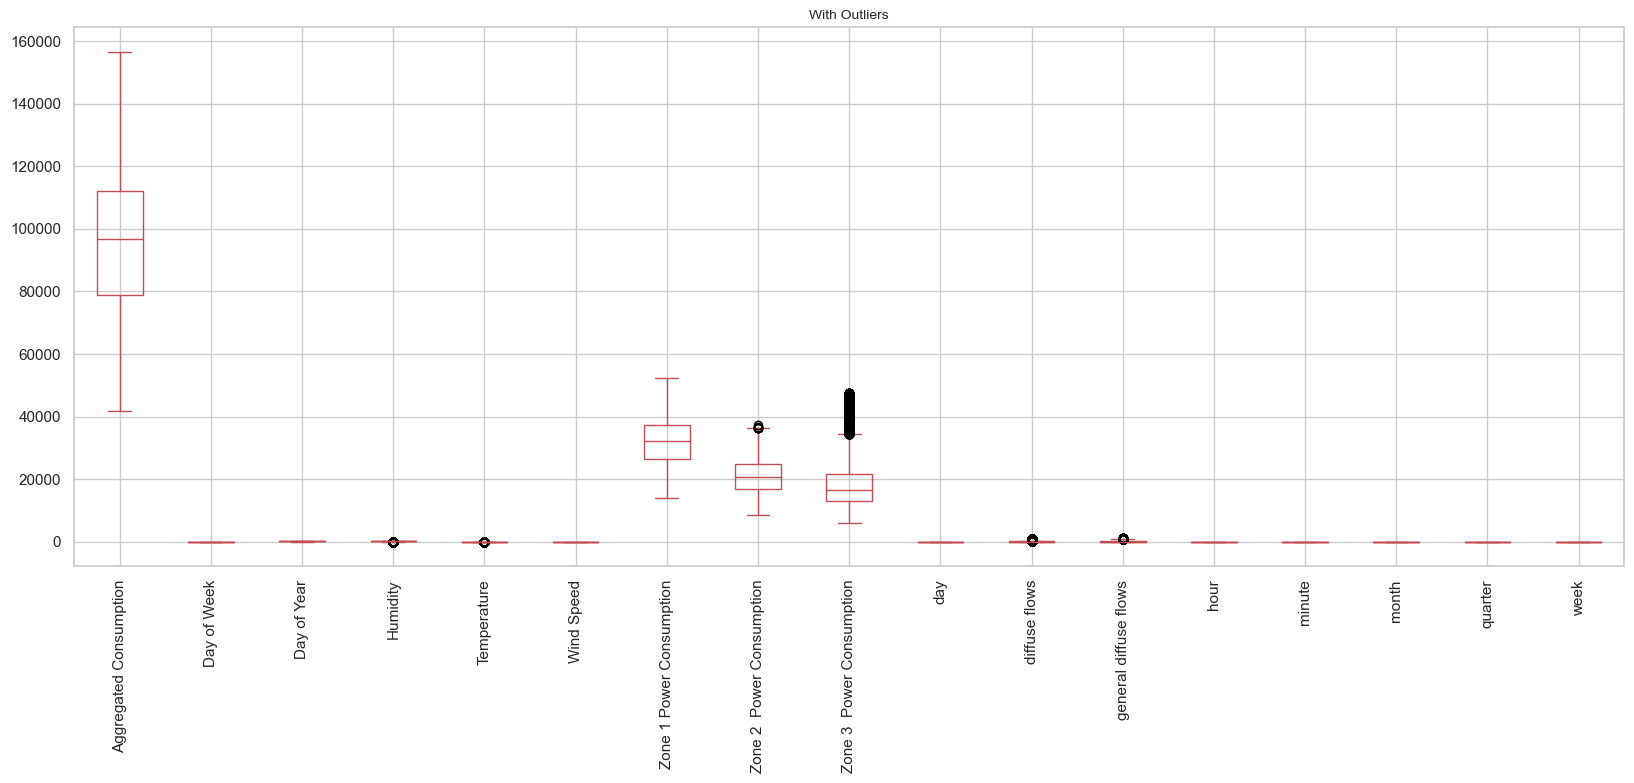

In [23]:
df[df.columns.difference(['Y house price of unit area'])].boxplot(figsize=(20,7),color='r',)
plt.xticks(rotation=90)
plt.title('With Outliers',fontsize=10)
plt.show()

##### Finding Outlier

In [24]:
def olf(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  ol=((df[column] < LB) | (df[column] > UB)).sum() 
  return print("Number of outliers in the column- {} is : {}".format(column,ol))

In [25]:
for i in num:
    olf(i)

Number of outliers in the column- DateTime is : 0
Number of outliers in the column- Temperature is : 142
Number of outliers in the column- Humidity is : 291
Number of outliers in the column- Wind Speed is : 0
Number of outliers in the column- general diffuse flows is : 2315
Number of outliers in the column- diffuse flows is : 4571
Number of outliers in the column- Zone 1 Power Consumption is : 0
Number of outliers in the column- Zone 2  Power Consumption is : 7
Number of outliers in the column- Zone 3  Power Consumption is : 1191
Number of outliers in the column- Aggregated Consumption is : 0
Number of outliers in the column- day is : 0
Number of outliers in the column- Day of Week is : 0
Number of outliers in the column- Day of Year is : 0
Number of outliers in the column- hour is : 0
Number of outliers in the column- minute is : 0
Number of outliers in the column- month is : 0
Number of outliers in the column- quarter is : 0
Number of outliers in the column- week is : 0


##### Treating the Outliers

In [26]:
def olt(column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  LB= Q1 - 1.5 * IQR
  UB= Q3 + 1.5 * IQR
  df[column]=np.where(df[column]>UB, UB, df[column])
  df[column]=np.where(df[column]<LB, LB, df[column])

In [27]:
num

['DateTime',
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption',
 'Aggregated Consumption',
 'day',
 'Day of Week',
 'Day of Year',
 'hour',
 'minute',
 'month',
 'quarter',
 'week']

In [28]:
num_olt=[
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'day',
 'Day of Week',
 'Day of Year',
 'hour',
 'minute',
 'month',
 'quarter',
 'week']

In [29]:
for i in num_olt:
    olt(i)

In [30]:
# Rechecking the outliers count. 
for i in num:
    olf(i)

Number of outliers in the column- DateTime is : 0
Number of outliers in the column- Temperature is : 0
Number of outliers in the column- Humidity is : 0
Number of outliers in the column- Wind Speed is : 0
Number of outliers in the column- general diffuse flows is : 0
Number of outliers in the column- diffuse flows is : 0
Number of outliers in the column- Zone 1 Power Consumption is : 0
Number of outliers in the column- Zone 2  Power Consumption is : 7
Number of outliers in the column- Zone 3  Power Consumption is : 1191
Number of outliers in the column- Aggregated Consumption is : 0
Number of outliers in the column- day is : 0
Number of outliers in the column- Day of Week is : 0
Number of outliers in the column- Day of Year is : 0
Number of outliers in the column- hour is : 0
Number of outliers in the column- minute is : 0
Number of outliers in the column- month is : 0
Number of outliers in the column- quarter is : 0
Number of outliers in the column- week is : 0


## EDA

In [31]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

[]
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption', 'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour', 'minute', 'month', 'quarter', 'week']


In [32]:
len(num)

18

In [33]:
num.remove('DateTime')

### Univariate Analysis

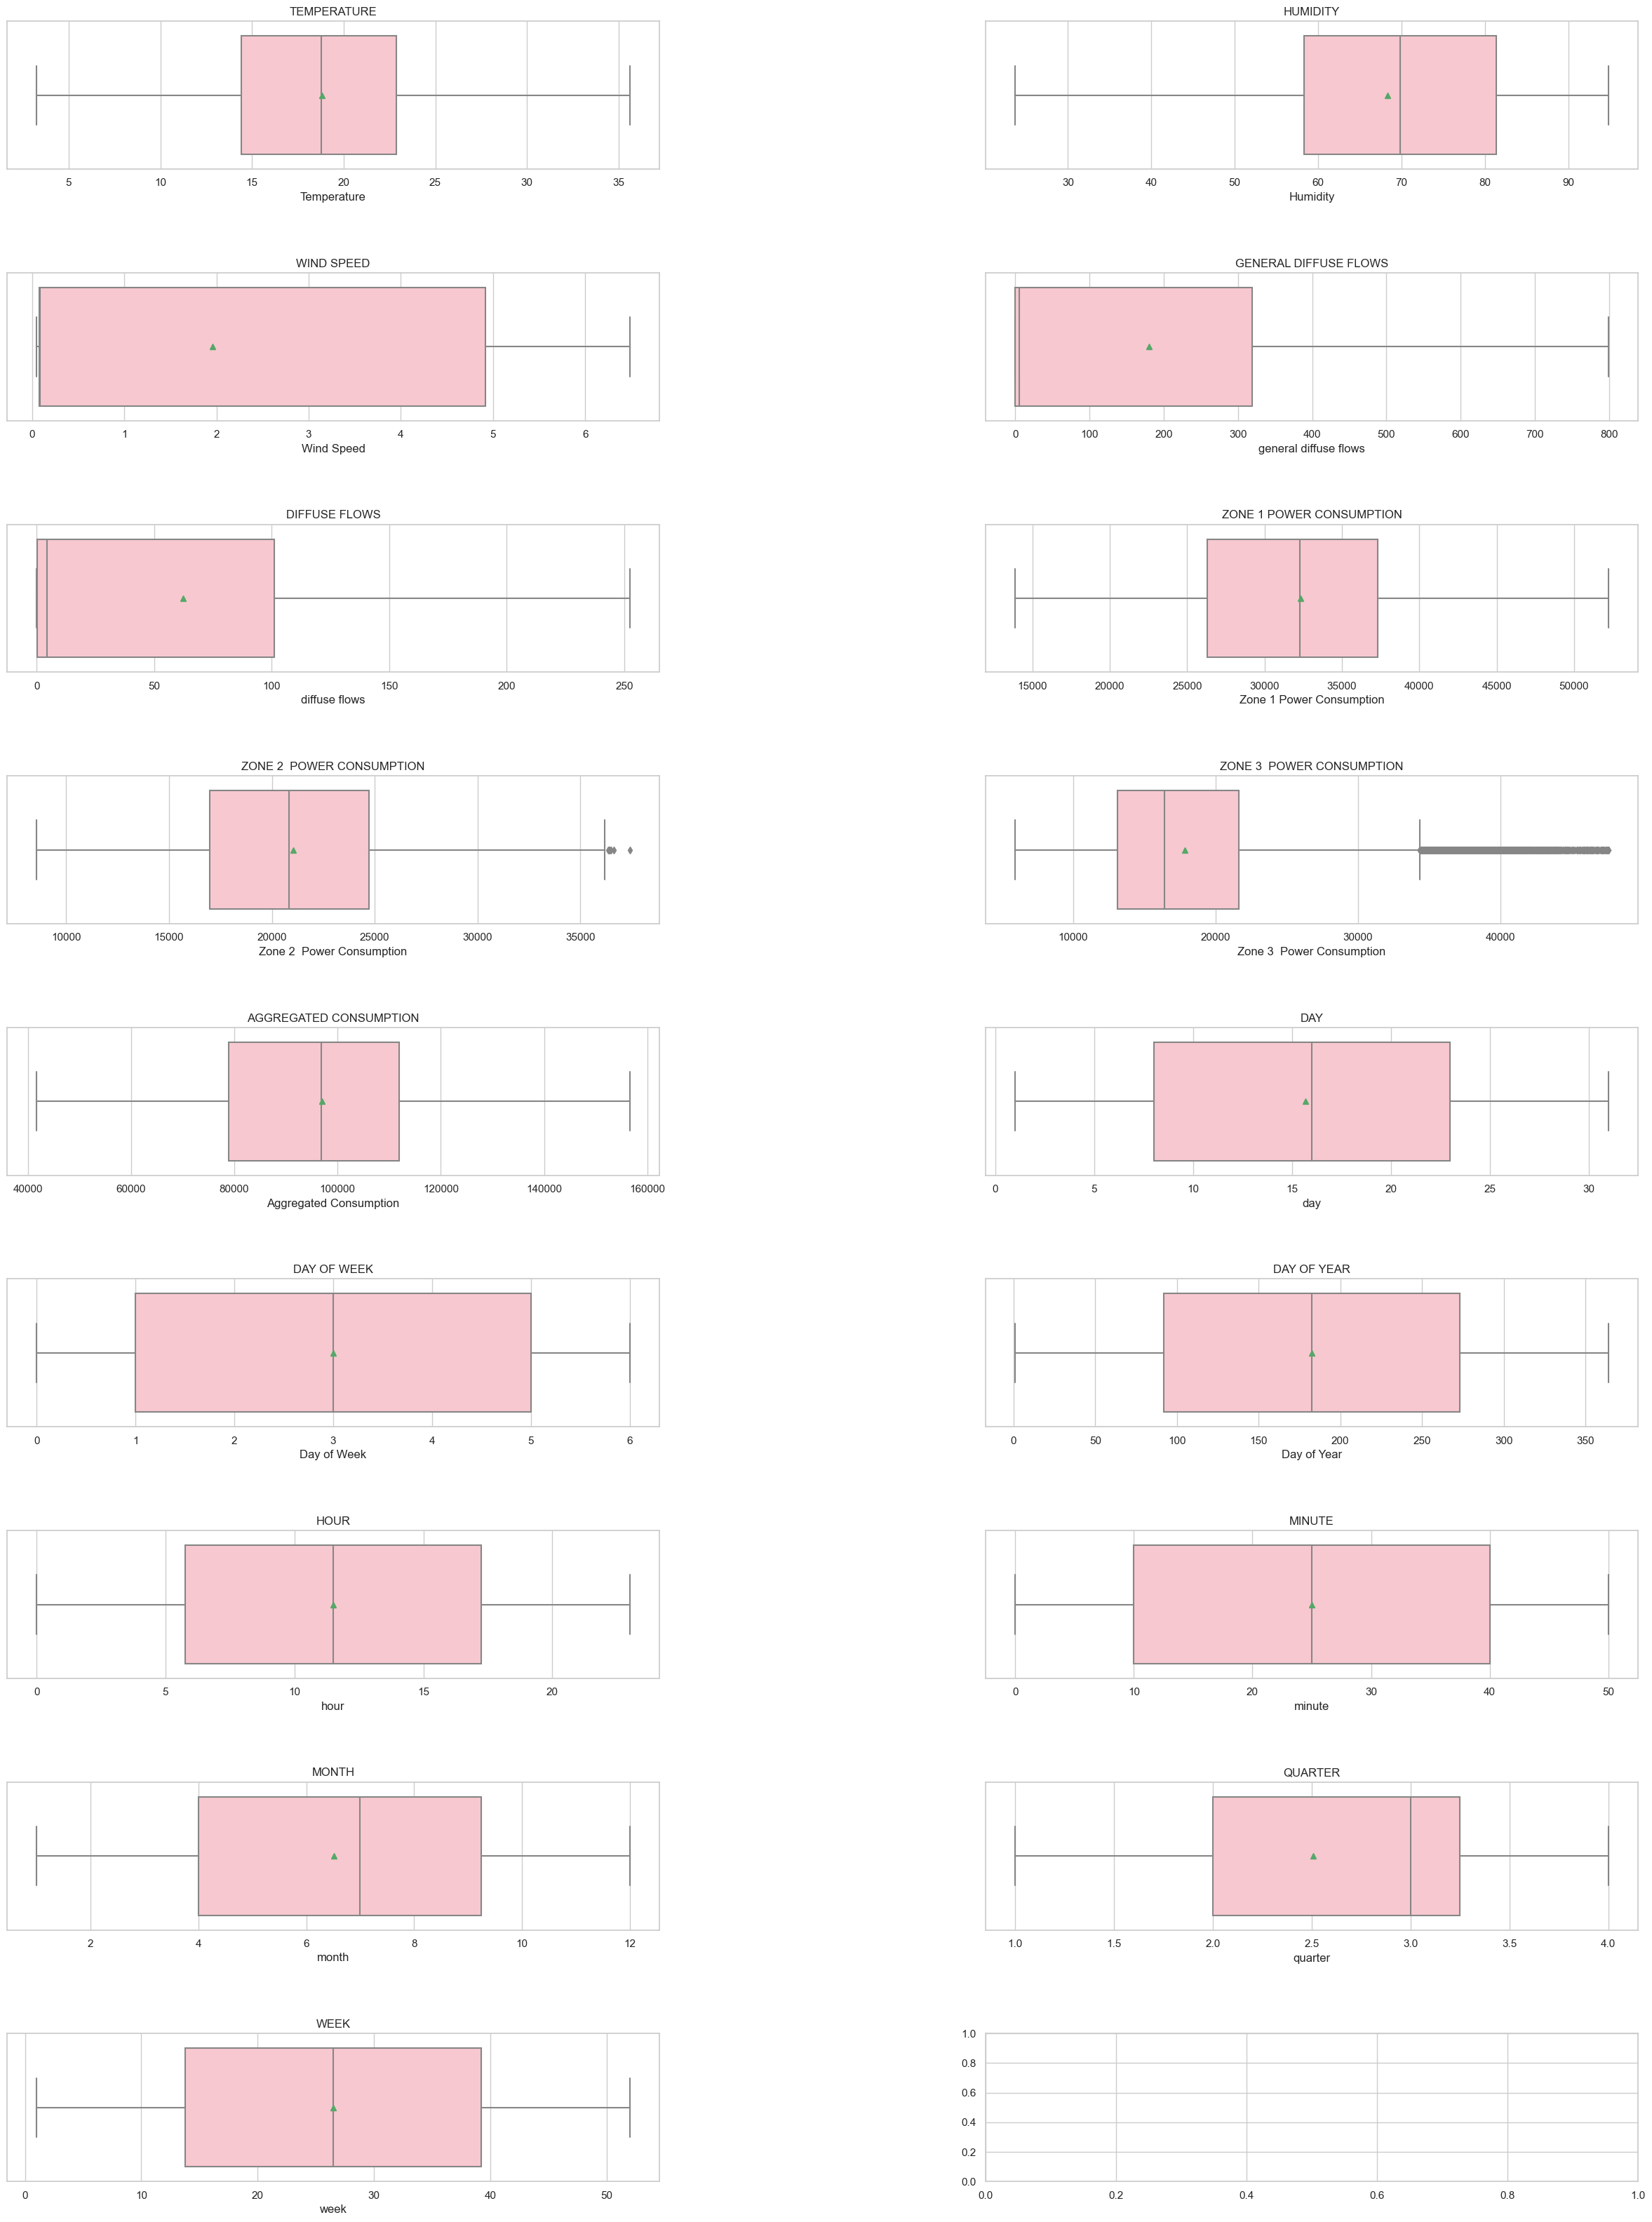

In [34]:
fig,axes = plt.subplots(9,2,figsize=(30,40))
plt.subplots_adjust(hspace=0.7,wspace=0.5)
for i,j in zip(num,axes.flatten()):
  sns.boxplot(x=i,data = df,ax=j,showmeans=True,color="pink")
  j.set_title(i.upper())

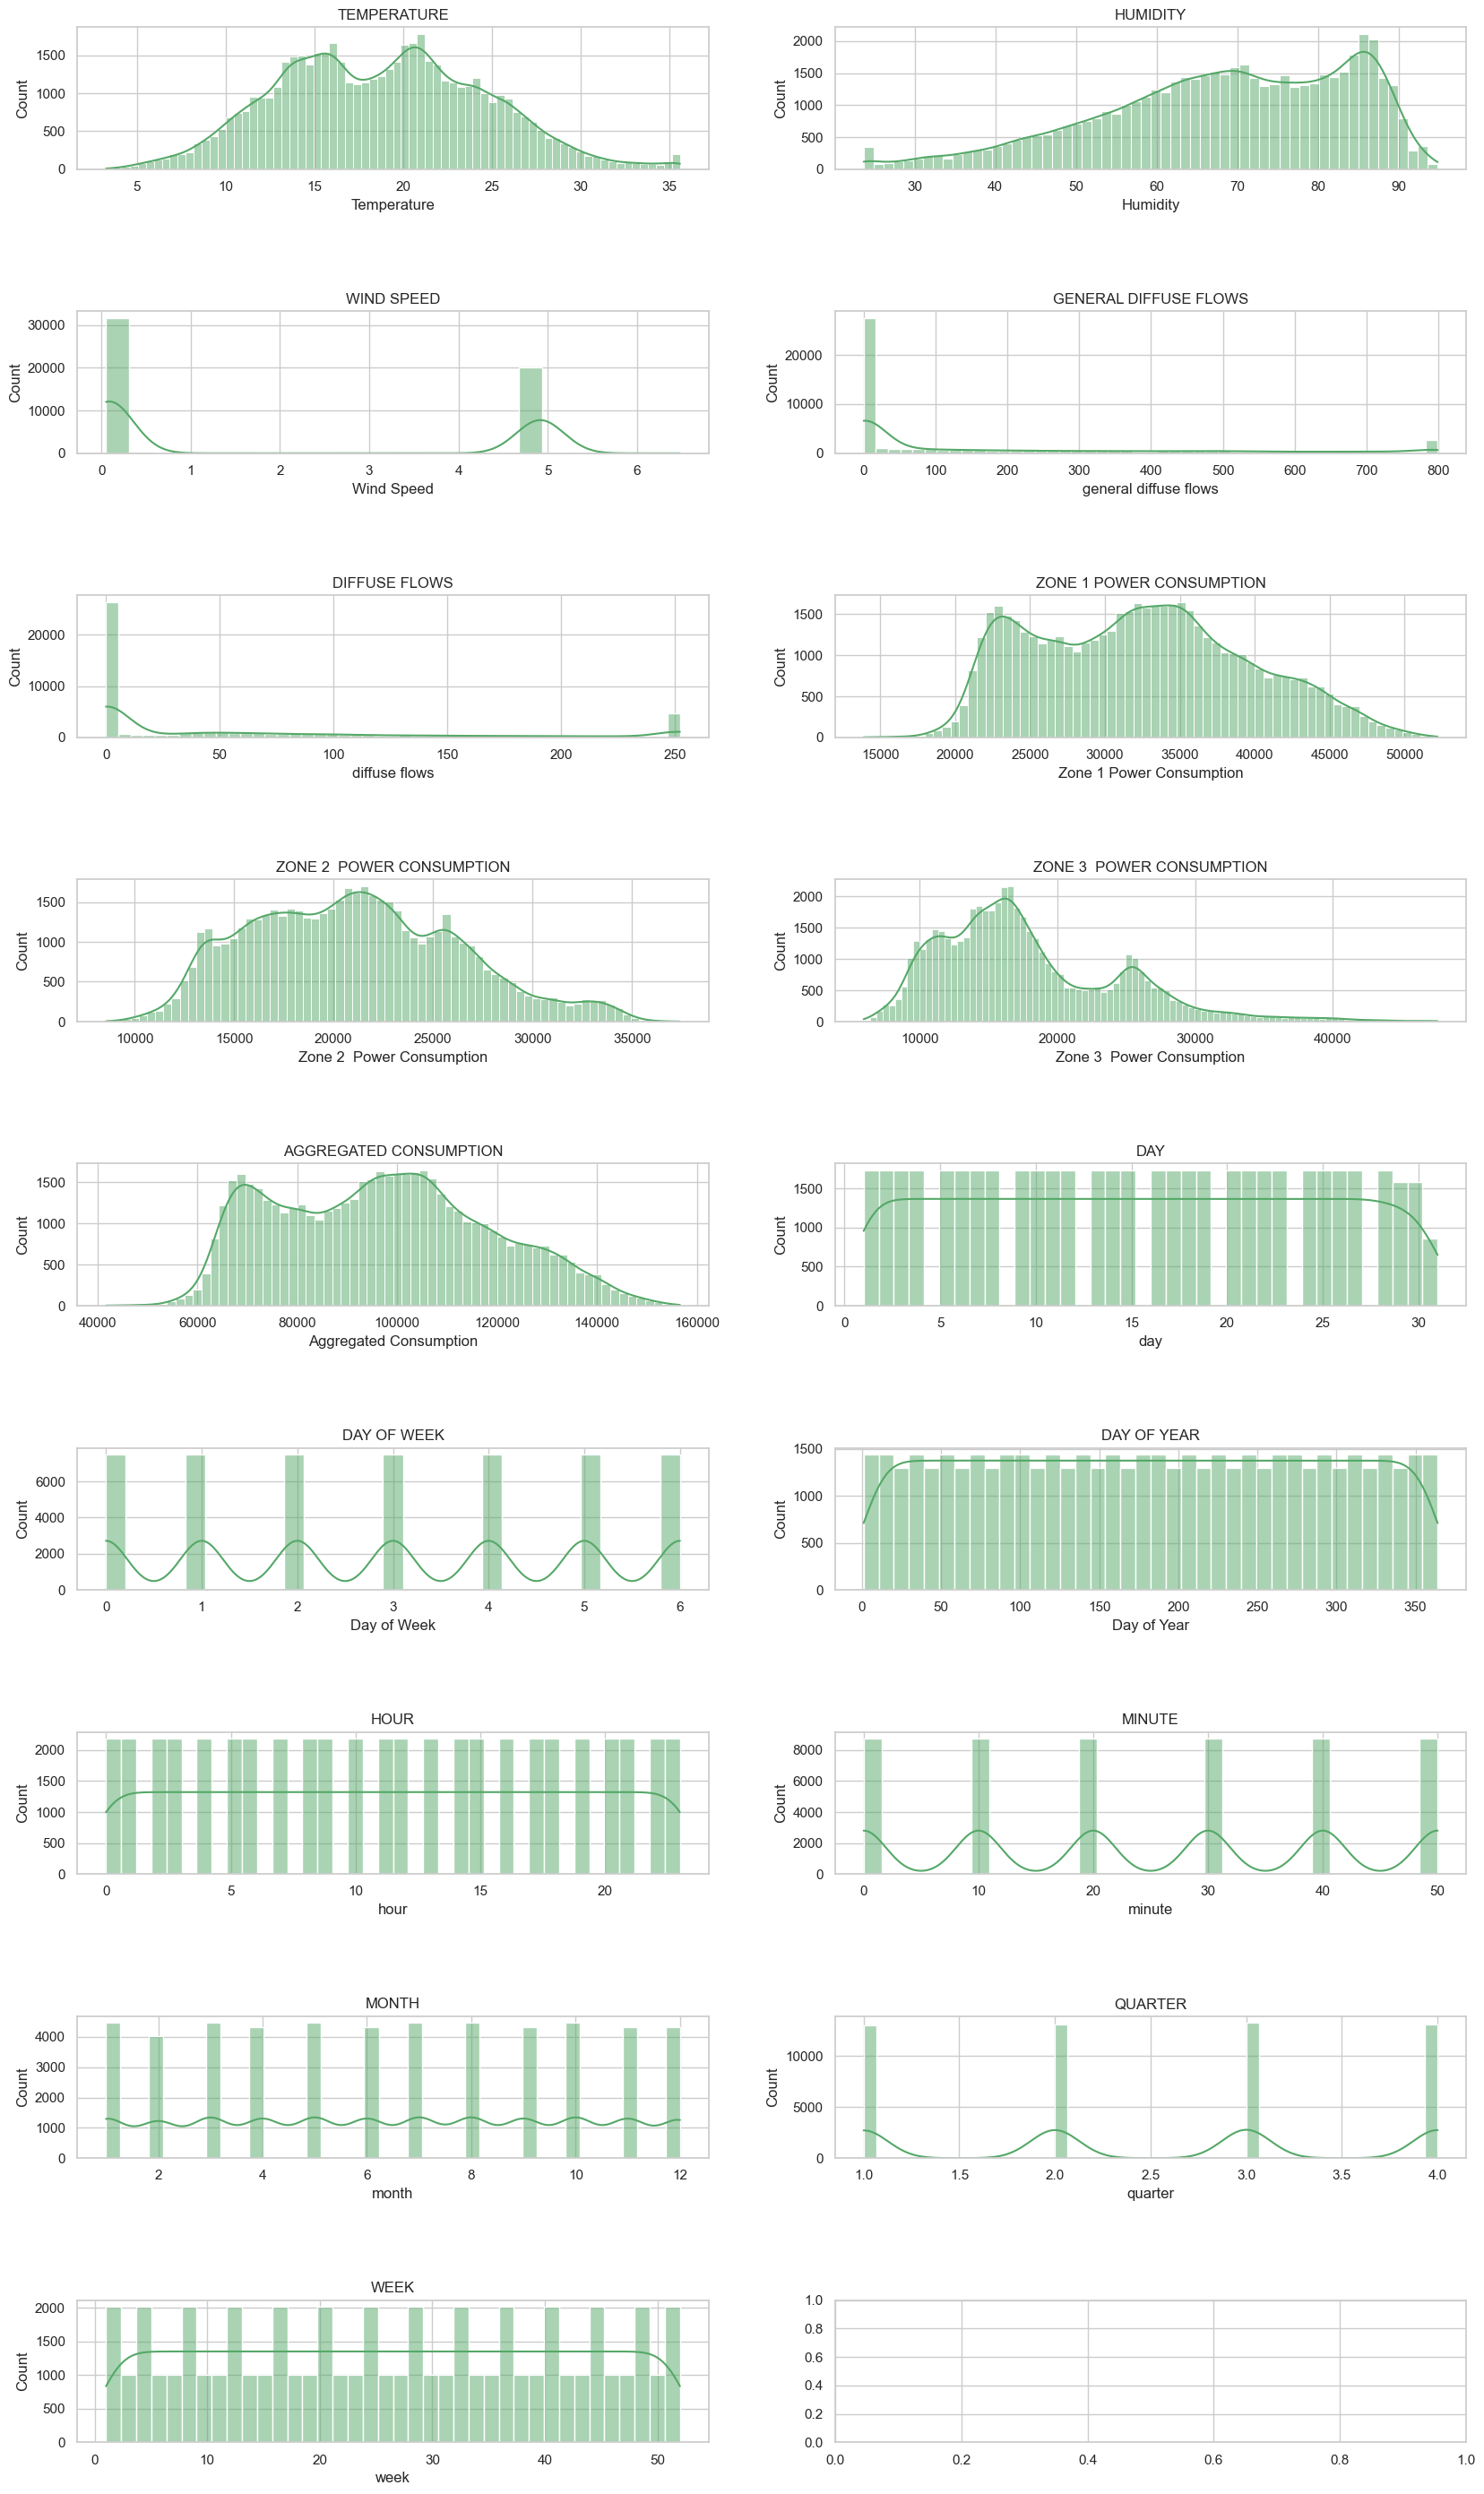

In [35]:
fig,axes = plt.subplots(9,2,figsize=(20,35))
plt.subplots_adjust(hspace=1,wspace=0.2)
for i,j in zip(num,axes.flatten()):
    sns.histplot(x=i,data = df,ax=j,kde=True,color='g')
    j.set_title(i.upper())

### Bivariate Analyisis

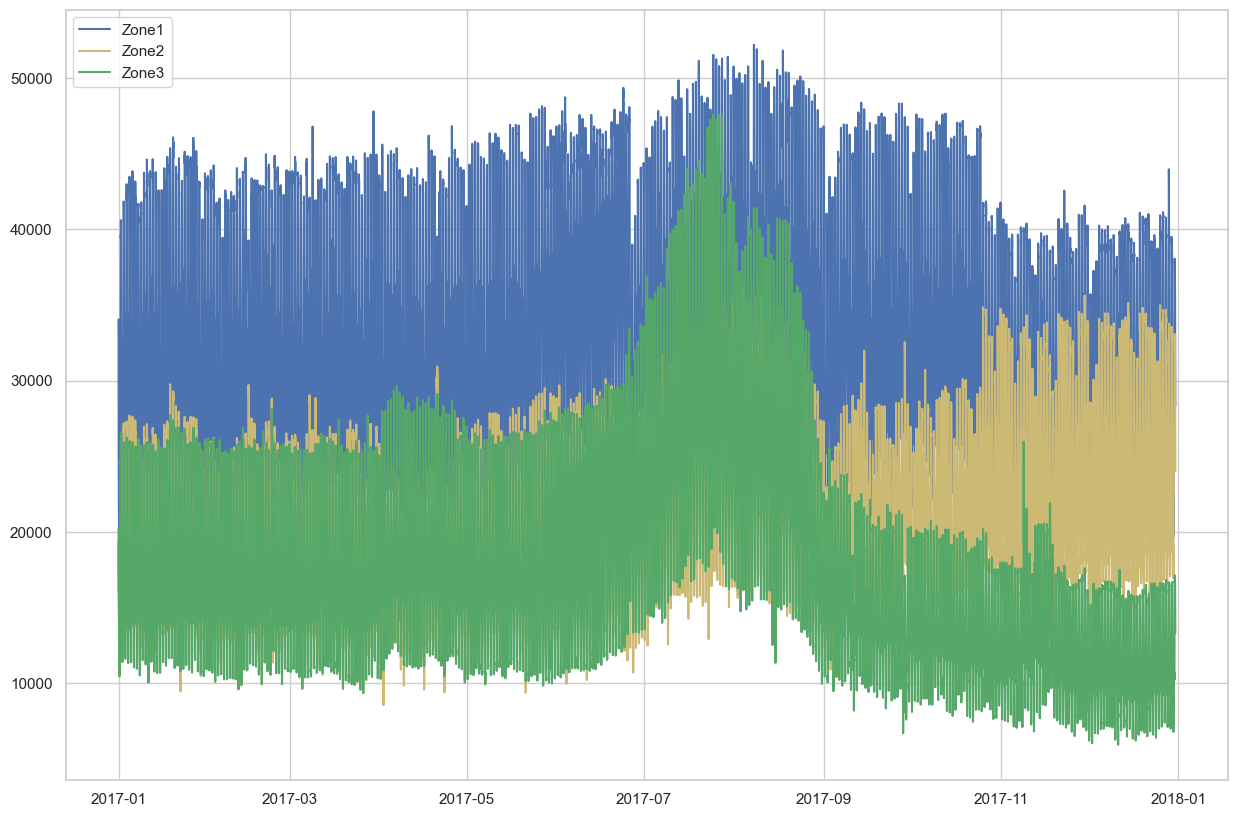

In [36]:
plt.figure(figsize=(15,10))
plt.plot( df["DateTime"], df[target1],'b-',label="Zone1")
plt.plot( df["DateTime"], df[target2],'y-',label="Zone2")
plt.plot( df["DateTime"], df[target3],'g-',label="Zone3")
plt.legend(loc="upper left")
plt.show()

<AxesSubplot:xlabel='Day of Week', ylabel='Zone 1 Power Consumption'>

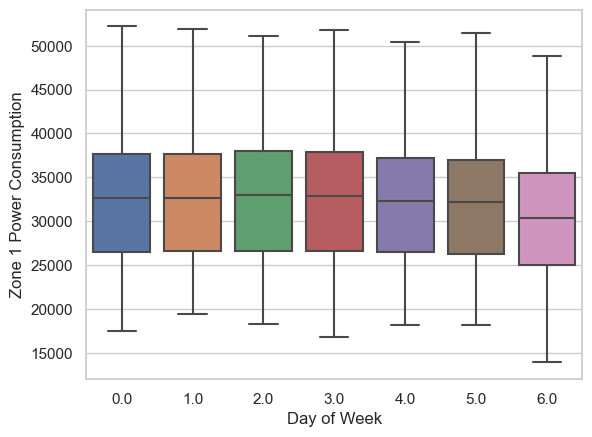

In [37]:
sns.boxplot(y=target1,data=df,x='Day of Week')

In [38]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour',
       'minute', 'month', 'quarter', 'week'],
      dtype='object')

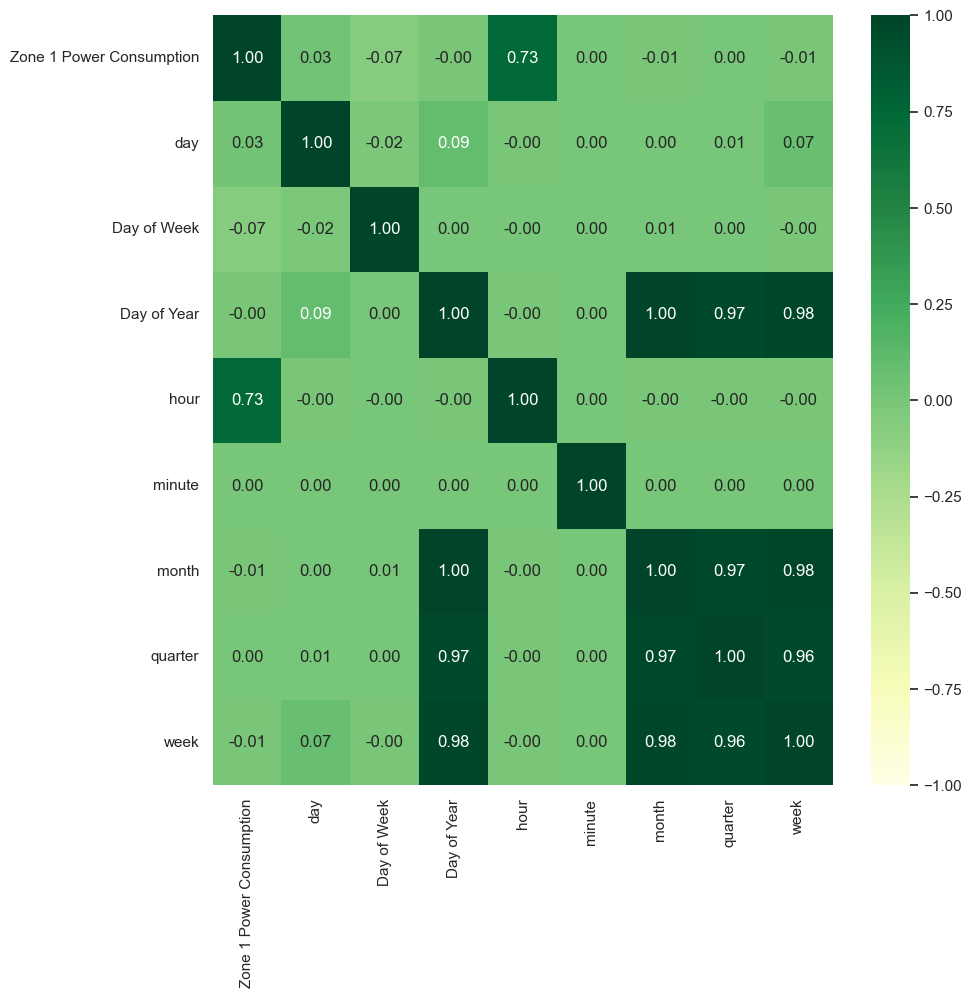

In [39]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target1,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

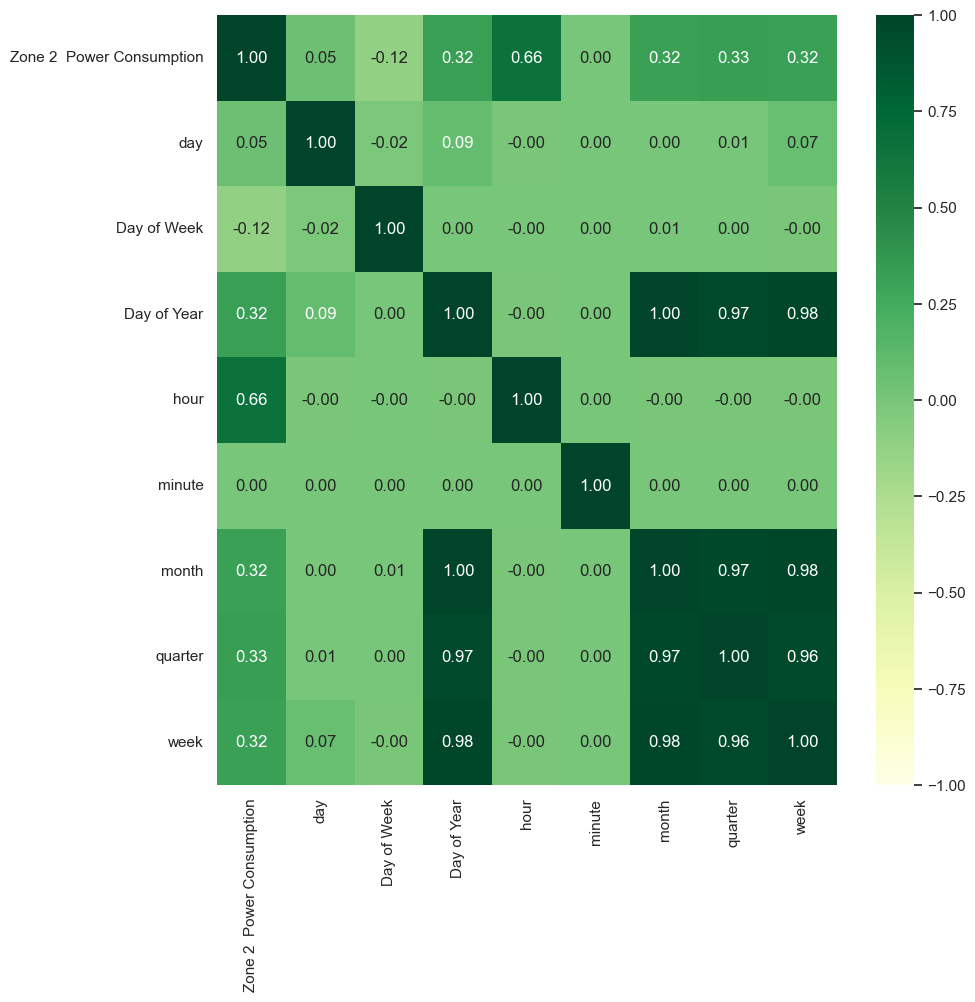

In [40]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target2,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

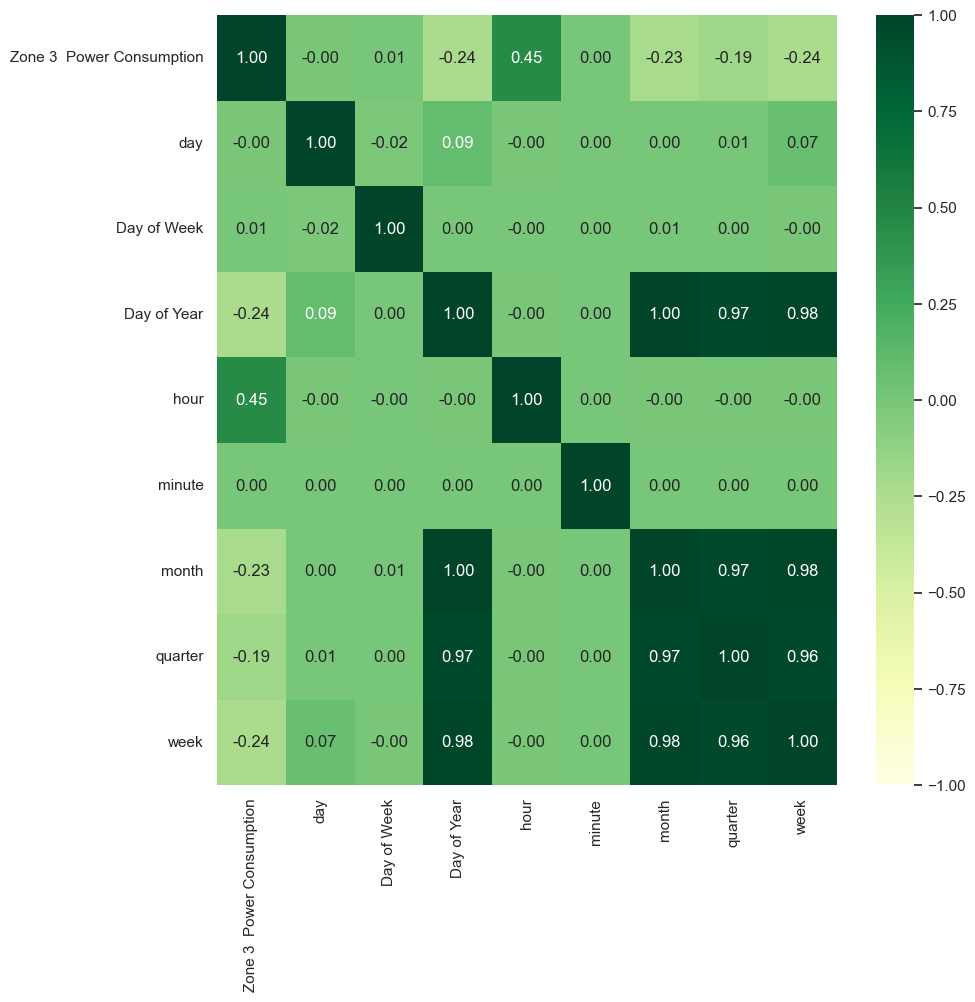

In [41]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target3,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

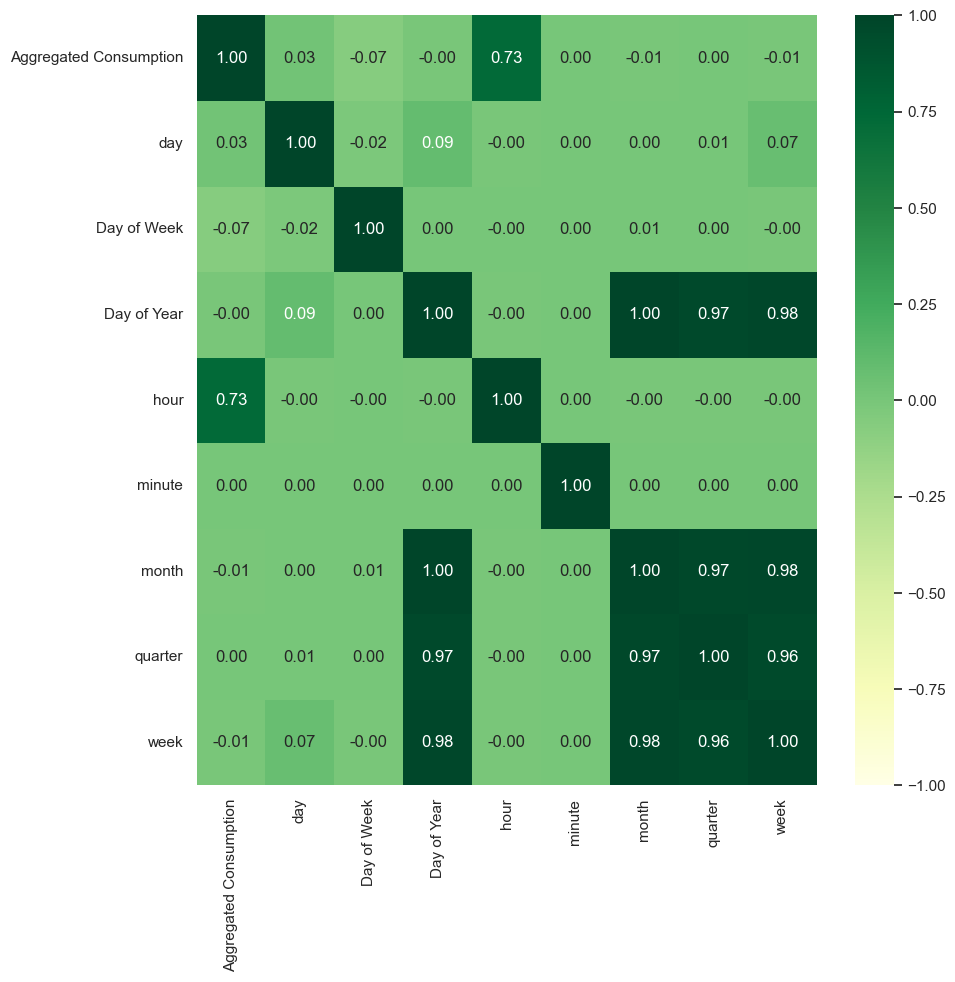

In [42]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target4,'day', 'Day of Week', 'Day of Year', 'hour','minute', 'month', 'quarter', 'week']].corr(), annot=True,fmt='.2f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

In [43]:
df.columns

Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption',
       'Aggregated Consumption', 'day', 'Day of Week', 'Day of Year', 'hour',
       'minute', 'month', 'quarter', 'week'],
      dtype='object')

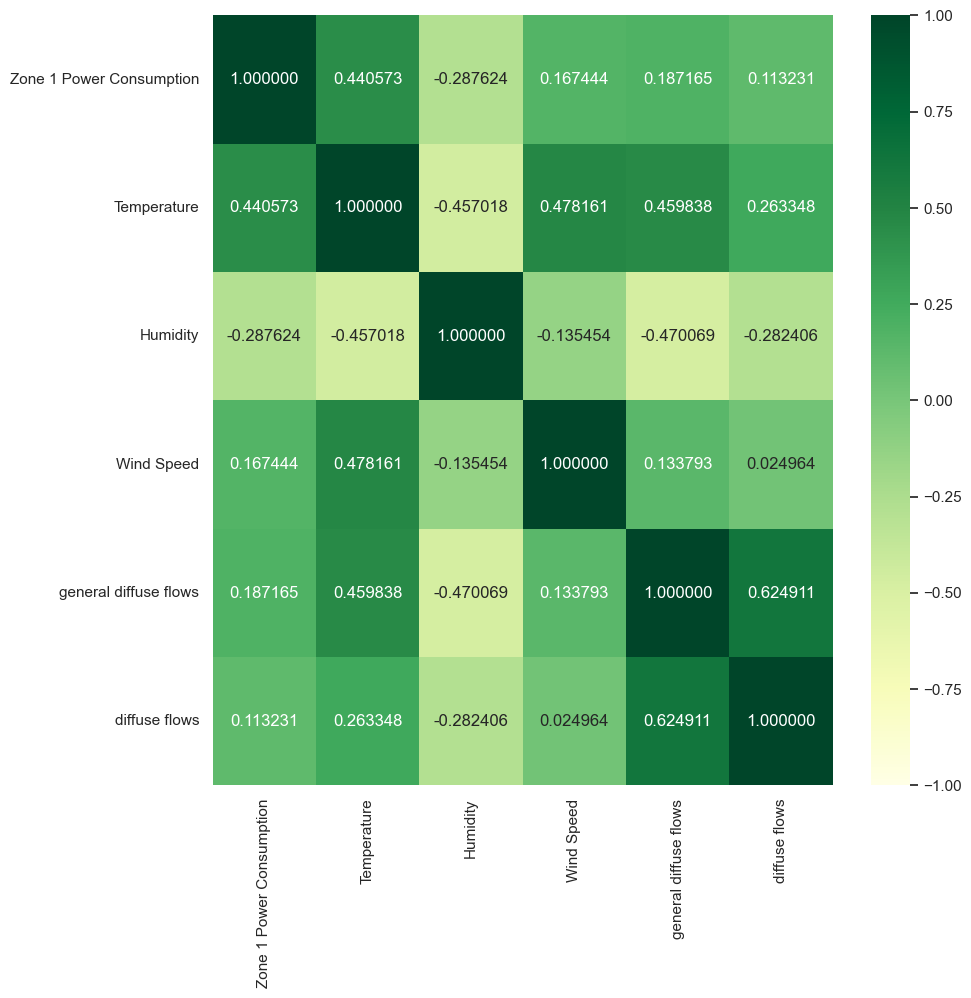

In [44]:
fig = plt.subplots(figsize=(10, 10))
sns.heatmap(df[[target1,'Temperature', 'Humidity', 'Wind Speed','general diffuse flows', 'diffuse flows']].corr(), annot=True,fmt='.6f',cmap="YlGn", center=0, vmin=-1, vmax=1);
plt.show()

In [45]:
target_List=[target1,target2,target3,target4]

In [46]:
del df['DateTime']

In [47]:
ipcols=['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows',
       'diffuse flows', 'day', 'Day of Week', 'Day of Year', 'hour', 'minute',
       'month', 'quarter', 'week']

## Feature Importance

In [48]:
from scipy.stats import chi2_contingency
for i in ipcols:
    contingency_table = pd.crosstab(df[i], df[target1])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    alpha = 0.01
    if p < alpha:
        print(f"{i} is significant because p value is :{p}.")
    else:
        print(f"{i} is NOT significant because p value is :{p} .")

Temperature is significant because p value is :8.21117831670087e-25.
Humidity is NOT significant because p value is :1.0 .
Wind Speed is significant because p value is :0.0.
general diffuse flows is significant because p value is :0.0.
diffuse flows is significant because p value is :0.0.
day is significant because p value is :3.7348745301717484e-33.
Day of Week is significant because p value is :2.1195033712390746e-11.
Day of Year is significant because p value is :0.0.
hour is significant because p value is :0.0.
minute is NOT significant because p value is :0.5736532440441496 .
month is significant because p value is :0.0.
quarter is significant because p value is :0.0.
week is significant because p value is :0.0.


# Model Preparation-10 minutes

In [49]:
X = df.drop(['Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption',
 'Aggregated Consumption','Humidity','minute'],axis=1) ## Removing Humidity and minute here as they are statistically insignificant.
y1 = np.array(df[target1])
y2 = np.array(df[target2])
y3 = np.array(df[target3])
y4 = np.array(df[target4])

In [50]:
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.3 , random_state=1)
_, _,  y2_train, y2_test = train_test_split(X, y2, test_size=0.3 , random_state=1)
_, _,  y3_train, y3_test = train_test_split(X, y3, test_size=0.3 , random_state=1)
_, _,  y4_train, y4_test = train_test_split(X, y4, test_size=0.3 , random_state=1)

In [51]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from keras import models, layers, optimizers, regularizers
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
# from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from tensorflow.keras.optimizers import Adam
from scipy.stats import uniform, randint
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
import statistics
from itertools import product

In [53]:

TrainRMSE=[]
TestRMSE=[]
TrainMAE=[]
TestMAE=[]
Target=[]
ChosenParameters=[]

## MLP

In [54]:
def MLPM(targets,y_train,y_test):
    modelname="MLP"
    target=targets+"_10m_"+modelname
    MLP_model= MLPRegressor()
    param_dist = {
        'hidden_layer_sizes': [(50,), (100,), (100, 100), (50, 50, 50)],
        'activation': ['tanh', 'relu'],
        'solver': ['sgd', 'adam'],
        'alpha': [0.0001, 0.05],
        'learning_rate': ['constant', 'adaptive'],
    }

    random_search = RandomizedSearchCV(
        MLP_model, 
        param_distributions=param_dist, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )

    random_search.fit(X_train_scaled, y_train)

    best_params = random_search.best_params_
    print("Best parameters found: ", best_params)

    model_MLP=random_search.best_estimator_
    rmse_tr=np.sqrt(mean_squared_error(y_train,model_MLP.predict(X_train_scaled)))
    mae_tr=mean_absolute_error(y_train,model_MLP.predict(X_train_scaled))

    rmse_te=np.sqrt(mean_squared_error(y_test,model_MLP.predict(X_test_scaled)))
    mae_te=mean_absolute_error(y_test,model_MLP.predict(X_test_scaled))
    ChosenParameters.append(best_params)
    Target.append(target)
    TrainRMSE.append(rmse_tr)
    TrainMAE.append(mae_tr)
    TestRMSE.append(rmse_te)
    TestMAE.append(mae_te)

In [55]:
MLPM(target1,y1_train,y1_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [56]:
MLPM(target2,y2_train,y2_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [57]:
MLPM(target3,y3_train,y3_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [58]:
MLPM(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [59]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters ,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730


## Adaptive Boosting

In [60]:
def ADABoost(targets,y_train,y_test):
    modelname="ADA Booster"
    target=targets+"_10m_"+modelname
    ADAB_model = AdaBoostRegressor(random_state=42)
    param_dist = {'n_estimators':list(np.arange(441,502,2)),
             'learning_rate':list(np.arange(0.11,0.2,0.000001))}

    random_search = RandomizedSearchCV(
        ADAB_model, 
        param_distributions=param_dist, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )

    random_search.fit(X_train_scaled, y_train)

    best_params = random_search.best_params_
    print("Best parameters found: ", best_params)

    model_ADAB=random_search.best_estimator_
    rmse_tr=np.sqrt(mean_squared_error(y_train,model_ADAB.predict(X_train_scaled)))
    mae_tr=mean_absolute_error(y_train,model_ADAB.predict(X_train_scaled))

    rmse_te=np.sqrt(mean_squared_error(y_test,model_ADAB.predict(X_test_scaled)))
    mae_te=mean_absolute_error(y_test,model_ADAB.predict(X_test_scaled))
    ChosenParameters.append(best_params)
    Target.append(target)
    TrainRMSE.append(rmse_tr)
    TrainMAE.append(mae_tr)
    TestRMSE.append(rmse_te)
    TestMAE.append(mae_te)

In [61]:
ADABoost(target1,y1_train,y1_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 455, 'learning_rate': 0.1993000000000893}


In [62]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters, 'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525


In [63]:
ADABoost(target2,y2_train,y2_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 449, 'learning_rate': 0.11897300000000897}


In [64]:
ADABoost(target3,y3_train,y3_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 443, 'learning_rate': 0.11355700000000356}


In [65]:
ADABoost(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 485, 'learning_rate': 0.1336180000000236}


In [66]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters ,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626


## Random Forest

In [67]:
def RF(targets,y_train,y_test):
        model="Random Forest"
        target=targets+"_10m_"+model
        model_RF = RandomForestRegressor(random_state=1)
        params_RF = {
                'n_estimators':[10,20, 30, 50, 100, 200, 300],
                'min_samples_split':list(range(1,3)),
                'max_features':list(range(1,5)),
                'min_samples_leaf':list(range(1,3))}
        random_search = RandomizedSearchCV(
        model_RF, 
        param_distributions=params_RF, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )
        random_search.fit(X_train_scaled, y_train)

        best_params = random_search.best_params_
        print("Best parameters found: ", best_params)

        RF_model=random_search.best_estimator_
        rmse_tr=np.sqrt(mean_squared_error(y_train,RF_model.predict(X_train)))
        mae_tr=mean_absolute_error(y_train,RF_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y_test,RF_model.predict(X_test)))
        mae_te=mean_absolute_error(y_test,RF_model.predict(X_test))
        ChosenParameters.append(best_params)
        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)


In [68]:
RF(target1,y1_train,y1_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [69]:
RF(target2,y2_train,y2_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [70]:
RF(target3,y3_train,y3_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [71]:
RF(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [72]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626
8,Zone 1 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",7244.362719,7249.609788,5995.243344,6013.828556
9,Zone 2 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",6408.483675,6427.107632,5326.809113,5345.707706


## KNN

In [73]:
def KNNM(targets,y_train,y_test):
    modelname="KNN"
    target=targets+"_10m_"+modelname
    model = KNeighborsRegressor()
    param_dist = {
        'n_neighbors': list(range(3,100,2)),  # Number of neighbors to use
        'weights': ['uniform', 'distance'],  # Weight function used in prediction
        'metric': ['euclidean', 'manhattan', 'minkowski'],  # Distance metric
        'p': [1, 2]  # Power parameter for the Minkowski metric
    }

    random_search = RandomizedSearchCV(
        model, 
        param_distributions=param_dist, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )

    random_search.fit(X_train_scaled, y_train)

    best_params = random_search.best_params_
    print("Best parameters found: ", best_params)

    model_1=random_search.best_estimator_
    rmse_tr=np.sqrt(mean_squared_error(y_train,model_1.predict(X_train_scaled)))
    mae_tr=mean_absolute_error(y_train,model_1.predict(X_train_scaled))

    rmse_te=np.sqrt(mean_squared_error(y_test,model_1.predict(X_test_scaled)))
    mae_te=mean_absolute_error(y_test,model_1.predict(X_test_scaled))
    ChosenParameters.append(best_params)
    Target.append(target)
    TrainRMSE.append(rmse_tr)
    TrainMAE.append(mae_tr)
    TestRMSE.append(rmse_te)
    TestMAE.append(mae_te)


In [74]:
KNNM(target1,y1_train,y1_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [75]:
KNNM(target2,y2_train,y2_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [76]:
KNNM(target3,y3_train,y3_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [77]:
KNNM(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [78]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626
8,Zone 1 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",7244.362719,7249.609788,5995.243344,6013.828556
9,Zone 2 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",6408.483675,6427.107632,5326.809113,5345.707706


# Model Preparation-1 hour model

In [79]:
df_Hourly

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Aggregated Consumption,day,Day of Week,Day of Year,hour,month,quarter,week
DateTime,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,2017-01-01 00:25:00,6.196833,75.066667,0.081833,0.063500,0.098833,175187.84810,108160.48632,115512.28916,525563.54430,1,6,1,0,1,1,52
2017-01-01 01:00:00,2017-01-01 01:25:00,5.548833,77.583333,0.082000,0.056833,0.112500,147943.29114,96470.51672,102257.34940,443829.87342,1,6,1,1,1,1,52
2017-01-01 02:00:00,2017-01-01 02:25:00,5.054333,78.933333,0.082333,0.063000,0.129167,132498.22784,85984.19453,94056.86747,397494.68352,1,6,1,2,1,1,52
2017-01-01 03:00:00,2017-01-01 03:25:00,5.004333,77.083333,0.082833,0.059833,0.141000,124866.83544,79316.71732,89303.13253,374600.50632,1,6,1,3,1,1,52
2017-01-01 04:00:00,2017-01-01 04:25:00,5.097667,74.050000,0.082333,0.058000,0.122833,122855.69620,77529.48328,85902.65060,368567.08860,1,6,1,4,1,1,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-30 19:00:00,2017-12-30 19:25:00,9.453333,62.406667,0.074667,0.052000,0.102000,225082.88974,194986.19208,101560.62425,675248.66922,30,5,364,19,12,4,52
2017-12-30 20:00:00,2017-12-30 20:25:00,9.041667,63.990000,0.080333,0.052667,0.105000,222053.23193,192121.50966,101992.79712,666159.69579,30,5,364,20,12,4,52
2017-12-30 21:00:00,2017-12-30 21:25:00,8.011667,69.675000,0.081500,0.073167,0.098333,212149.04943,184547.40718,99653.30132,636447.14829,30,5,364,21,12,4,52


In [80]:
del df_Hourly['DateTime']

In [81]:
X = df_Hourly.drop(['Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption',
 'Aggregated Consumption','Humidity'],axis=1) ## Removing Humidity here as they are statistically insignificant.
y1 = np.array(df_Hourly[target1])
y2 = np.array(df_Hourly[target2])
y3 = np.array(df_Hourly[target3])
y4 = np.array(df_Hourly[target4])

In [82]:
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.3 , random_state=1)
_, _,  y2_train, y2_test = train_test_split(X, y2, test_size=0.3 , random_state=1)
_, _,  y3_train, y3_test = train_test_split(X, y3, test_size=0.3 , random_state=1)
_, _,  y4_train, y4_test = train_test_split(X, y4, test_size=0.3 , random_state=1)

In [83]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

## MLP

In [84]:
def MLPM(targets,y_train,y_test):
    modelname="MLP"
    target=targets+"_1H_"+modelname
    MLP_model= MLPRegressor()
    param_dist = {
        'hidden_layer_sizes': [(50,), (100,), (100, 100), (50, 50, 50)],
        'activation': ['tanh', 'relu'],
        'solver': ['sgd', 'adam'],
        'alpha': [0.0001, 0.05],
        'learning_rate': ['constant', 'adaptive'],
    }

    random_search = RandomizedSearchCV(
        MLP_model, 
        param_distributions=param_dist, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )

    random_search.fit(X_train_scaled, y_train)

    best_params = random_search.best_params_
    print("Best parameters found: ", best_params)

    model_MLP=random_search.best_estimator_
    rmse_tr=np.sqrt(mean_squared_error(y_train,model_MLP.predict(X_train_scaled)))
    mae_tr=mean_absolute_error(y_train,model_MLP.predict(X_train_scaled))

    rmse_te=np.sqrt(mean_squared_error(y_test,model_MLP.predict(X_test_scaled)))
    mae_te=mean_absolute_error(y_test,model_MLP.predict(X_test_scaled))
    ChosenParameters.append(best_params)
    Target.append(target)
    TrainRMSE.append(rmse_tr)
    TrainMAE.append(mae_tr)
    TestRMSE.append(rmse_te)
    TestMAE.append(mae_te)

In [85]:
MLPM(target1,y1_train,y1_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [86]:
MLPM(target2,y2_train,y2_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [87]:
MLPM(target3,y3_train,y3_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [88]:
MLPM(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50, 50, 50), 'alpha': 0.05, 'activation': 'relu'}


In [89]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters ,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626
8,Zone 1 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",7244.362719,7249.609788,5995.243344,6013.828556
9,Zone 2 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",6408.483675,6427.107632,5326.809113,5345.707706


## Adaptive Boosting

In [90]:
def ADABoost(targets,y_train,y_test):
    modelname="ADA Booster"
    target=targets+"_1H_"+modelname
    ADAB_model = AdaBoostRegressor(random_state=42)
    param_dist = {'n_estimators':list(np.arange(441,502,2)),
             'learning_rate':list(np.arange(0.11,0.2,0.000001))}

    random_search = RandomizedSearchCV(
        ADAB_model, 
        param_distributions=param_dist, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )

    random_search.fit(X_train_scaled, y_train)

    best_params = random_search.best_params_
    print("Best parameters found: ", best_params)

    model_ADAB=random_search.best_estimator_
    rmse_tr=np.sqrt(mean_squared_error(y_train,model_ADAB.predict(X_train_scaled)))
    mae_tr=mean_absolute_error(y_train,model_ADAB.predict(X_train_scaled))

    rmse_te=np.sqrt(mean_squared_error(y_test,model_ADAB.predict(X_test_scaled)))
    mae_te=mean_absolute_error(y_test,model_ADAB.predict(X_test_scaled))
    ChosenParameters.append(best_params)
    Target.append(target)
    TrainRMSE.append(rmse_tr)
    TrainMAE.append(mae_tr)
    TestRMSE.append(rmse_te)
    TestMAE.append(mae_te)

In [91]:
ADABoost(target1,y1_train,y1_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 443, 'learning_rate': 0.11355700000000356}


In [92]:
ADABoost(target2,y2_train,y2_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 489, 'learning_rate': 0.18330100000007332}


In [93]:
ADABoost(target3,y3_train,y3_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 443, 'learning_rate': 0.11355700000000356}


In [94]:
ADABoost(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 443, 'learning_rate': 0.11355700000000356}


In [95]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters ,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626
8,Zone 1 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",7244.362719,7249.609788,5995.243344,6013.828556
9,Zone 2 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",6408.483675,6427.107632,5326.809113,5345.707706


## Random Forest

In [96]:
def RF(targets,y_train,y_test):
        model="Random Forest"
        target=targets+"_1H_"+model
        model_RF = RandomForestRegressor(random_state=1)
        params_RF = {
                'n_estimators':[10,20, 30, 50, 100, 200, 300],
                'min_samples_split':list(range(1,3)),
                'max_features':list(range(1,5)),
                'min_samples_leaf':list(range(1,3))}
        random_search = RandomizedSearchCV(
        model_RF, 
        param_distributions=params_RF, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )
        random_search.fit(X_train_scaled, y_train)

        best_params = random_search.best_params_
        print("Best parameters found: ", best_params)

        RF_model=random_search.best_estimator_
        rmse_tr=np.sqrt(mean_squared_error(y_train,RF_model.predict(X_train)))
        mae_tr=mean_absolute_error(y_train,RF_model.predict(X_train))

        rmse_te=np.sqrt(mean_squared_error(y_test,RF_model.predict(X_test)))
        mae_te=mean_absolute_error(y_test,RF_model.predict(X_test))
        ChosenParameters.append(best_params)
        Target.append(target)
        TrainRMSE.append(rmse_tr)
        TrainMAE.append(mae_tr)
        TestRMSE.append(rmse_te)
        TestMAE.append(mae_te)


In [97]:
RF(target1,y1_train,y1_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [98]:
RF(target2,y2_train,y2_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [99]:
RF(target3,y3_train,y3_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [100]:
RF(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 4}


In [101]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626
8,Zone 1 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",7244.362719,7249.609788,5995.243344,6013.828556
9,Zone 2 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",6408.483675,6427.107632,5326.809113,5345.707706


## KNN

In [102]:
def KNNM(targets,y_train,y_test):
    modelname="KNN"
    target=targets+"_1H_"+modelname
    model = KNeighborsRegressor()
    param_dist = {
        'n_neighbors': list(range(3,100,2)),  # Number of neighbors to use
        'weights': ['uniform', 'distance'],  # Weight function used in prediction
        'metric': ['euclidean', 'manhattan', 'minkowski'],  # Distance metric
        'p': [1, 2]  # Power parameter for the Minkowski metric
    }

    random_search = RandomizedSearchCV(
        model, 
        param_distributions=param_dist, 
        n_iter=15,  # Number of parameter settings sampled
        cv=5,  # Number of folds in cross-validation
        scoring='neg_mean_absolute_error',  # Metric to optimize
        verbose=1,
        random_state=42,
        n_jobs=-1  # Use all available CPUs
    )

    random_search.fit(X_train_scaled, y_train)

    best_params = random_search.best_params_
    print("Best parameters found: ", best_params)

    model_1=random_search.best_estimator_
    rmse_tr=np.sqrt(mean_squared_error(y_train,model_1.predict(X_train_scaled)))
    mae_tr=mean_absolute_error(y_train,model_1.predict(X_train_scaled))

    rmse_te=np.sqrt(mean_squared_error(y_test,model_1.predict(X_test_scaled)))
    mae_te=mean_absolute_error(y_test,model_1.predict(X_test_scaled))
    ChosenParameters.append(best_params)
    Target.append(target)
    TrainRMSE.append(rmse_tr)
    TrainMAE.append(mae_tr)
    TestRMSE.append(rmse_te)
    TestMAE.append(mae_te)


In [103]:
KNNM(target1,y1_train,y1_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [104]:
KNNM(target2,y2_train,y2_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [105]:
KNNM(target3,y3_train,y3_test)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [106]:
KNNM(target4,y4_train,y4_test)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found:  {'weights': 'uniform', 'p': 2, 'n_neighbors': 3, 'metric': 'minkowski'}


In [107]:
metric_df = pd.DataFrame({'Target+Sampling+Model':Target,'Best Fit Parameter':ChosenParameters,'TrainRMSE':TrainRMSE,'TestRMSE':TestRMSE,'TrainMAE':TrainMAE,'TestMAE':TestMAE})
metric_df

,Target+Sampling+Model,Best Fit Parameter,TrainRMSE,TestRMSE,TrainMAE,TestMAE
0,Zone 1 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1923.649438,1895.075012,1433.745554,1413.488332
1,Zone 2 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1399.166810,1380.771893,1056.598852,1041.725942
2,Zone 3 Power Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",1226.028871,1238.057468,919.453666,934.761468
3,Aggregated Consumption_10m_MLP,"{'solver': 'adam', 'learning_rate': 'constant'...",7097.826532,7015.003995,5307.126478,5208.787730
4,Zone 1 Power Consumption_10m_ADA Booster,"{'n_estimators': 455, 'learning_rate': 0.19930...",3093.418126,3042.105861,2496.492263,2437.110525
5,Zone 2 Power Consumption_10m_ADA Booster,"{'n_estimators': 449, 'learning_rate': 0.11897...",2291.925307,2279.192789,1858.169813,1841.021984
6,Zone 3 Power Consumption_10m_ADA Booster,"{'n_estimators': 443, 'learning_rate': 0.11355...",2627.048983,2660.904934,2137.164322,2167.142011
7,Aggregated Consumption_10m_ADA Booster,"{'n_estimators': 485, 'learning_rate': 0.13361...",9315.104895,9163.056280,7529.851406,7359.753626
8,Zone 1 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",7244.362719,7249.609788,5995.243344,6013.828556
9,Zone 2 Power Consumption_10m_Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",6408.483675,6427.107632,5326.809113,5345.707706


# Data Cleaning

In [108]:
for i in range(len(metric_df)):
    metric_df.loc[i,"Target"]= metric_df['Target+Sampling+Model'][i].split("_")[0]
    metric_df.loc[i,"sampling"]= metric_df['Target+Sampling+Model'][i].split("_")[1]
    metric_df.loc[i,"Model"]= metric_df['Target+Sampling+Model'][i].split("_")[2]
    

In [109]:
with pd.ExcelWriter('Novel metrics_Cleaned.xlsx') as writer:  # doctest: +SKIP
    metric_df.to_excel(writer,index=False, sheet_name='Cleaned')